# Lesson 20A: Matrix Factorisation Family — NMF and ICA (Theory)

## Introduction

Lesson 5 built PCA: $X \approx U\Sigma V^T$, orthogonal directions of maximum variance. It is the right tool when the data genuinely decomposes into uncorrelated, holistic modes of variation — but orthogonality is a strong assumption, and nothing about most real data guarantees it. A face is not built from components that cancel each other out with negative weights; a document is not a signed combination of topics; a microphone does not record the negative of a conversation. When the true generative structure is "parts that add up" or "independent causes that mix," PCA's orthogonality constraint is the wrong inductive bias, and it shows up as components that are only interpretable as abstract directions, not as parts or causes.

This lesson introduces two other members of the same factorisation family, each swapping orthogonality for a different, often more physically meaningful constraint:

- **NMF** (non-negative matrix factorisation): $X \approx WH$, with $W, H \ge 0$. The constraint is non-negativity, and the payoff is parts-based, purely additive components.
- **ICA** (independent component analysis): $X = AS$, with the rows of $S$ statistically independent. The constraint is independence, and the payoff is recovering the actual generative causes, not just a variance-ranked basis.

Both give up something PCA has for free: a unique, orthogonal, easily-computed solution. Both from-scratch implementations in this notebook are validated against a production library and against synthetic data with a KNOWN ground truth — the only way to check "did we actually recover the right answer" for a method whose solution is not unique the way PCA's is.

In this lesson:
1. The factorisation family, compared by the constraint that defines each member
2. NMF: the Frobenius and KL objectives, multiplicative updates derived from gradient descent, monotone decrease, non-uniqueness
3. ICA and the cocktail-party model: why Gaussian sources are unidentifiable, non-Gaussianity measures, whitening
4. FastICA: the fixed-point algorithm derived from a negentropy approximation
5. Practical guidance on which factorisation fits which inductive bias

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [The Factorisation Family](#family)
4. [Non-negative Matrix Factorisation](#nmf)
5. [Independent Component Analysis: The Cocktail-Party Model](#ica)
6. [FastICA: The Fixed-Point Algorithm](#fastica)
7. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import NMF as SKNMF, FastICA as SKFastICA, PCA as SKPCA
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: sklearn's bundled load_digits() plus in-notebook synthetic signals — nothing downloaded.")

Data: sklearn's bundled load_digits() plus in-notebook synthetic signals — nothing downloaded.


<a name="family"></a>
## The Factorisation Family

All three methods write a data matrix $X \in \mathbb{R}^{n \times d}$ ($n$ samples, $d$ features) as a product of two factors, and differ only in what they constrain:

| Method | Model | Constraint | What's unique |
|---|---|---|---|
| PCA (Lesson 5) | $X \approx U \Sigma V^T$ | columns of $V$ orthonormal | up to sign, for distinct eigenvalues |
| NMF | $X \approx WH$ | $W \ge 0,\ H \ge 0$ | not unique — permutation AND scaling both free |
| ICA | $X = AS$ | rows of $S$ statistically independent | up to permutation, sign, and scale |

PCA's orthogonality is a mathematical convenience — the eigendecomposition of the covariance matrix — not a claim about how the data was generated. NMF's non-negativity and ICA's independence are, by contrast, claims about the generative process itself: "this data is built from parts that only add" or "this data is a mixture of independent causes." When that claim is true, the corresponding method recovers something PCA structurally cannot: a face's parts (eyebrows, nose bridge, cheekbone shading) rather than eigenfaces that must be added AND subtracted to reconstruct a face; or a speaker's voice rather than an abstract direction of maximum variance across the recording.

The next two sections build NMF and ICA from their defining constraints and check, numerically, exactly where PCA's orthogonal solution fails to be a parts-based or independent-causes solution.

PCA on digits: 47.3% of the 8 leading components' pixel weights are NEGATIVE.
A held pixel weight of -0.3 does not mean 'a third of a stroke is missing' -- it means
this component only makes sense added AND subtracted against others. There is no reading
of a negative pixel intensity as a 'part' of a digit.


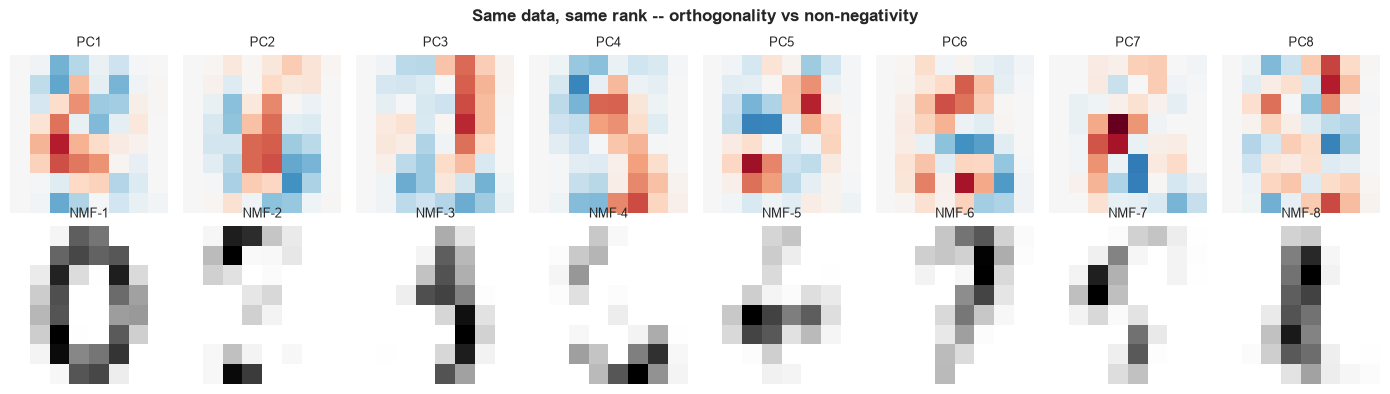


NMF components: 0.0% negative entries (exactly 0, by
construction of the non-negativity constraint) -- every component is addable-only, and each
visibly concentrates on a stroke region rather than mixing bright and dark across the whole digit.
Lesson 20B pushes this comparison further with a dedicated parts-based decomposition study.


In [2]:
digits = load_digits()
X_digits = digits.data.astype(float)  # 1797 x 64, pixel intensities in [0, 16] -- already non-negative

pca = SKPCA(n_components=8, random_state=SEED).fit(X_digits)
neg_frac = (pca.components_ < 0).mean()
print(f"PCA on digits: {neg_frac:.1%} of the 8 leading components' pixel weights are NEGATIVE.")
print("A held pixel weight of -0.3 does not mean 'a third of a stroke is missing' -- it means")
print("this component only makes sense added AND subtracted against others. There is no reading")
print("of a negative pixel intensity as a 'part' of a digit.")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(pca.components_[i].reshape(8, 8), cmap='RdBu_r',
                      vmin=-np.abs(pca.components_).max(), vmax=np.abs(pca.components_).max())
    axes[0, i].set_title(f'PC{i+1}', fontsize=9)
    axes[0, i].axis('off')
nmf_preview = SKNMF(n_components=8, init='nndsvda', random_state=SEED, max_iter=500).fit(X_digits)
for i in range(8):
    axes[1, i].imshow(nmf_preview.components_[i].reshape(8, 8), cmap='Greys', vmin=0)
    axes[1, i].set_title(f'NMF-{i+1}', fontsize=9)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('PCA\n(signed)', fontsize=10)
axes[1, 0].set_ylabel('NMF\n(non-negative)', fontsize=10)
plt.suptitle('Same data, same rank -- orthogonality vs non-negativity', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNMF components: {(nmf_preview.components_ < 0).mean():.1%} negative entries (exactly 0, by")
print("construction of the non-negativity constraint) -- every component is addable-only, and each")
print("visibly concentrates on a stroke region rather than mixing bright and dark across the whole digit.")
print("Lesson 20B pushes this comparison further with a dedicated parts-based decomposition study.")

<a name="nmf"></a>
## Non-negative Matrix Factorisation

**The objective.** Given $X \ge 0$ (elementwise), find $W \in \mathbb{R}^{n \times k}_{\ge 0}$ and $H \in \mathbb{R}^{k \times d}_{\ge 0}$ minimising the reconstruction error. Two common choices:

$$J_{\text{Frob}}(W, H) = \tfrac{1}{2}\|X - WH\|_F^2 = \tfrac{1}{2}\sum_{ij}\left(X_{ij} - (WH)_{ij}\right)^2$$

$$J_{\text{KL}}(W, H) = \sum_{ij}\left(X_{ij}\log\frac{X_{ij}}{(WH)_{ij}} - X_{ij} + (WH)_{ij}\right)$$

the KL form treating $X$ and $WH$ as (unnormalised) distributions, appropriate when $X$ is count-like data.

**Deriving the multiplicative update (Lee & Seung, 2001).** Take the Frobenius objective. Ordinary gradient descent on $H$ is $H \leftarrow H - \eta \odot \nabla_H J$ (elementwise), with

$$\nabla_H J = W^T(WH - X) = W^TWH - W^TX.$$

The trick is the choice of step size: instead of one global $\eta$, use a matrix of step sizes $\eta_{aj} = H_{aj} / (W^TWH)_{aj}$ — proportional to the current value, inversely proportional to the positive part of the gradient. Substituting:

$$H_{aj} \leftarrow H_{aj} - \frac{H_{aj}}{(W^TWH)_{aj}}\Big[(W^TWH)_{aj} - (W^TX)_{aj}\Big] = H_{aj}\,\frac{(W^TX)_{aj}}{(W^TWH)_{aj}}.$$

The $H_{aj}$ and $-H_{aj}$ terms cancel exactly, leaving a purely **multiplicative** update — no subtraction anywhere, so if $W, H$ start strictly positive they stay non-negative forever with no explicit clipping. The symmetric update for $W$ is

$$W_{ia} \leftarrow W_{ia}\,\frac{(XH^T)_{ia}}{(WHH^T)_{ia}}.$$

Lee and Seung prove (via an auxiliary-function / majorize-minimize argument, not reproduced here) that alternating these two updates never increases $J_{\text{Frob}}$. That is a claim about every step of every run — exactly the kind of claim this notebook checks numerically rather than takes on faith.

monotone decrease check over 300 iterations:
  max step-to-step INCREASE in the objective: -2.699e-05 (no increase found)
  objective: 178.5949 -> 0.0028

reconstruction of a KNOWN rank-4 non-negative matrix:
  final relative Frobenius error: 0.0007
  sklearn NMF (same k, same data): 0.0023
  agreement: from-scratch and sklearn reach comparable reconstruction error (yes)

non-uniqueness (scaling ambiguity), constructed rather than hoped for:
  max |reconstruction difference| after rescaling W,H by a random positive diagonal: 4.44e-16
  yet W itself changed by up to 0.780 elementwise -- WH is invariant, W and H are not.
  Unlike PCA's discrete sign ambiguity, this is a CONTINUOUS family of equally-valid factorisations:
  'the' NMF solution for a given X, k is not a single (W, H) pair, it is an equivalence class.


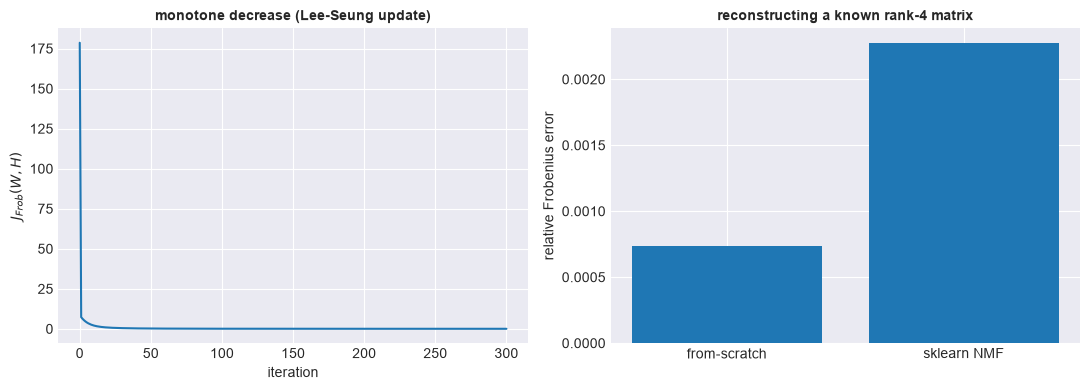

In [3]:
def nmf_multiplicative(X, k, n_iter=300, seed=0, eps=1e-10):
    rng_local = np.random.default_rng(seed)
    n, d = X.shape
    W = rng_local.uniform(0.1, 1.0, size=(n, k))
    H = rng_local.uniform(0.1, 1.0, size=(k, d))
    errors = np.empty(n_iter + 1)
    errors[0] = 0.5 * np.sum((X - W @ H) ** 2)
    for t in range(n_iter):
        H *= (W.T @ X) / (W.T @ W @ H + eps)
        W *= (X @ H.T) / (W @ H @ H.T + eps)
        errors[t + 1] = 0.5 * np.sum((X - W @ H) ** 2)
    return W, H, errors


# Ground truth: a genuinely non-negative, exactly rank-4 matrix, so "did we recover it" is checkable.
n, d, k_true = 200, 40, 4
W_true = rng.uniform(0, 1, size=(n, k_true))
H_true = rng.uniform(0, 1, size=(k_true, d))
X_synth = W_true @ H_true

W_hat, H_hat, errors = nmf_multiplicative(X_synth, k=k_true, n_iter=300, seed=SEED)

increases = np.diff(errors)
print(f"monotone decrease check over {len(errors)-1} iterations:")
print(f"  max step-to-step INCREASE in the objective: {increases.max():.3e} "
      f"({'no increase found' if increases.max() <= 1e-8 else 'VIOLATION'})")
print(f"  objective: {errors[0]:.4f} -> {errors[-1]:.4f}")

final_relerr = np.linalg.norm(X_synth - W_hat @ H_hat) / np.linalg.norm(X_synth)
print(f"\nreconstruction of a KNOWN rank-{k_true} non-negative matrix:")
print(f"  final relative Frobenius error: {final_relerr:.4f}")

sk_nmf = SKNMF(n_components=k_true, init='random', random_state=SEED, max_iter=300).fit(X_synth)
sk_relerr = np.linalg.norm(X_synth - sk_nmf.transform(X_synth) @ sk_nmf.components_) / np.linalg.norm(X_synth)
print(f"  sklearn NMF (same k, same data): {sk_relerr:.4f}")
print(f"  agreement: from-scratch and sklearn reach comparable reconstruction error "
      f"({'yes' if abs(final_relerr - sk_relerr) < 0.05 else 'NO -- investigate'})")

# Non-uniqueness: a continuous scaling ambiguity, guaranteed by construction rather than
# left to the luck of which local optimum a random init happens to land on. For ANY positive
# diagonal D, (W @ D, D^-1 @ H) reconstructs IDENTICALLY to (W, H) -- a strictly larger
# ambiguity than PCA's discrete sign flip, since D ranges over a continuous family.
D_diag = rng.uniform(0.5, 2.0, size=k_true)
W_rescaled = W_hat * D_diag
H_rescaled = H_hat / D_diag[:, None]
recon_diff = np.abs(W_hat @ H_hat - W_rescaled @ H_rescaled).max()
factor_diff = np.abs(W_hat - W_rescaled).max()
print(f"\nnon-uniqueness (scaling ambiguity), constructed rather than hoped for:")
print(f"  max |reconstruction difference| after rescaling W,H by a random positive diagonal: {recon_diff:.2e}")
print(f"  yet W itself changed by up to {factor_diff:.3f} elementwise -- WH is invariant, W and H are not.")
print(f"  Unlike PCA's discrete sign ambiguity, this is a CONTINUOUS family of equally-valid factorisations:")
print(f"  'the' NMF solution for a given X, k is not a single (W, H) pair, it is an equivalence class.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(errors, lw=1.5)
axes[0].set_xlabel('iteration'); axes[0].set_ylabel(r'$J_{Frob}(W,H)$')
axes[0].set_title('monotone decrease (Lee-Seung update)', fontweight='bold', fontsize=10)
axes[1].bar(['from-scratch', 'sklearn NMF'], [final_relerr, sk_relerr])
axes[1].set_ylabel('relative Frobenius error')
axes[1].set_title(f'reconstructing a known rank-{k_true} matrix', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="ica"></a>
## Independent Component Analysis: The Cocktail-Party Model

**The model.** $n$ microphones record a linear mixture of $n$ independent source signals: $x(t) = A\,s(t)$, where $A$ is an unknown, invertible $n\times n$ mixing matrix and the components of $s(t)$ are **statistically independent** (a much stronger claim than PCA's "uncorrelated"). The goal: recover $s(t)$ — and implicitly $A^{-1}$ — from $x(t)$ alone, with no knowledge of $A$ or $s$.

**Why Gaussian sources are unidentifiable.** Suppose every $s_i$ is i.i.d. standard Gaussian. For ANY orthogonal matrix $Q$ ($QQ^T = I$), the rotated vector $Qs$ is *also* i.i.d. standard Gaussian — jointly Gaussian random variables are independent exactly when uncorrelated, and $\mathrm{Cov}(Qs) = Q\,\mathrm{Cov}(s)\,Q^T = QIQ^T = I$, so $Qs$ is uncorrelated (hence independent) with the same marginal distribution as $s$. Then

$$x = As = (AQ^T)(Qs),$$

so the SAME observed $x$ is exactly as well explained by mixing matrix $AQ^T$ acting on sources $Qs$, for every orthogonal $Q$. There is no information in $x$ that could ever distinguish $A$ from $AQ^T$ — the model is unidentifiable up to an arbitrary rotation whenever the sources are Gaussian. (The formal general statement is the Darmois–Skitovich theorem: at most one of the sources may be Gaussian for identifiability; the rotation argument above is the checkable special case of two Gaussians.) Non-Gaussianity is not a technical convenience — it is the entire reason ICA can work at all.

**Measuring non-Gaussianity.** Two practical proxies:

$$\text{kurtosis}(y) = \mathbb{E}[y^4] - 3 \quad (y \text{ standardised, zero mean, unit variance})$$

zero for Gaussian, positive for super-Gaussian / heavy-tailed distributions, negative for sub-Gaussian / bounded distributions such as the uniform. And **negentropy**,

$$J(y) = H(y_{\text{gauss}}) - H(y) \ge 0,\qquad J(y) = 0 \iff y \text{ is Gaussian},$$

which is the "right" theoretical measure (the Gaussian is the maximum-entropy distribution for a given variance) but requires a density estimate to compute directly. FastICA below uses a tractable approximation instead.

**Whitening.** Before searching for the unmixing matrix, transform $x$ so its covariance is the identity: $z = \Lambda^{-1/2}U^Tx$, where $U\Lambda U^T$ is the eigendecomposition of $\mathrm{Cov}(x)$ — this is exactly Lesson 5's PCA machinery, reused rather than reinvented, followed by a per-axis rescale to unit variance. Whitening does not solve ICA (an orthogonal ambiguity remains, which is precisely the ambiguity the rotation argument above shows Gaussian sources cannot resolve), but it reduces the search from *all* invertible matrices to *orthogonal* matrices only — from $n^2$ free parameters down to $n(n-1)/2$, a reduction FastICA exploits directly in the next section.

Gaussian sources rotated by two DIFFERENT angles -- statistically indistinguishable if so:
  angle 1 (36 deg): cov = [[0.968, -0.002], [-0.002, 1.039]], kurtosis(axis0) = -0.113
  angle 2 (55 deg): cov = [[0.976, -0.023], [-0.023, 1.031]], kurtosis(axis0) = -0.102
  both covariances are ~identity and both kurtoses are ~0 -- no statistic here can tell the two
  rotation angles apart, which is the rotation-invariance argument made numerically concrete.

kurtosis vs rotation angle, Gaussian source: range [-0.117, +0.005] -- flat, no preferred angle
kurtosis vs rotation angle, uniform source:  range [-1.174, -0.569] -- varies with angle, a real signal to search over

whitening check: cov(X) before = [ 0.34 -0.32 -0.18  0.15] (not identity)
                  cov(Z) after  = [ 1.  0.  0. -0.] (identity, as required)


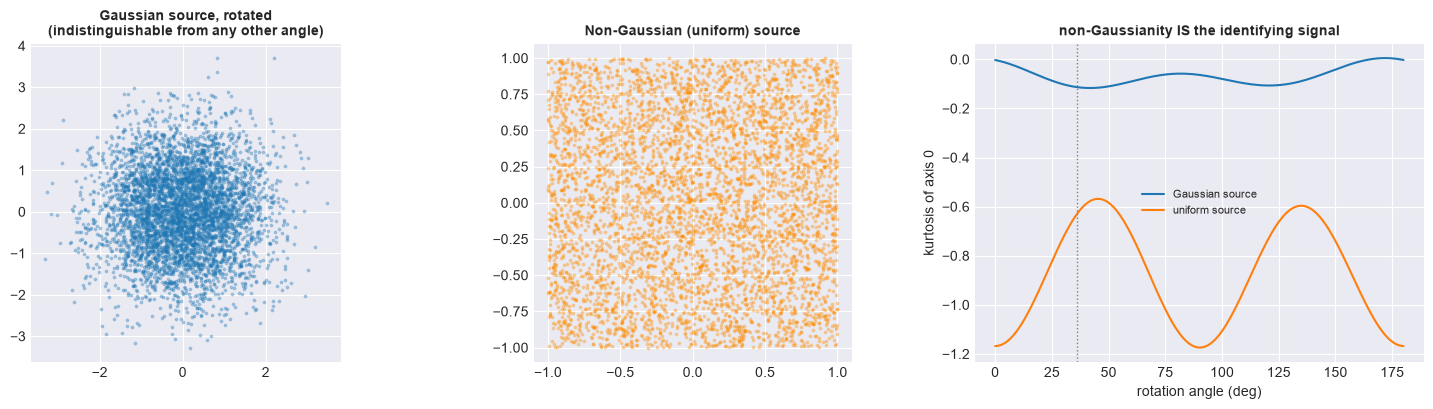

In [4]:
def whiten(X):
    # Reuses Lesson 5A's PCA machinery (eigendecomposition of the covariance) directly,
    # then rescales each axis to unit variance -- whitening IS PCA plus one extra step.
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)
    Z = Xc @ eigvecs @ np.diag(1.0 / np.sqrt(eigvals))
    return Z


def kurtosis(y):
    y = (y - y.mean()) / y.std()
    return np.mean(y ** 4) - 3.0


# --- Gaussian sources: rotation invariance, verified numerically ---
n_samples = 5000
s_gauss = rng.standard_normal((n_samples, 2))  # already i.i.d. standard Gaussian -> "whitened" by construction
theta_true = np.pi / 5
Q1 = np.array([[np.cos(theta_true), -np.sin(theta_true)], [np.sin(theta_true), np.cos(theta_true)]])
theta_other = np.pi / 3.3
Q2 = np.array([[np.cos(theta_other), -np.sin(theta_other)], [np.sin(theta_other), np.cos(theta_other)]])

rotated_true = s_gauss @ Q1.T
rotated_other = s_gauss @ Q2.T
print("Gaussian sources rotated by two DIFFERENT angles -- statistically indistinguishable if so:")
print(f"  angle 1 ({np.degrees(theta_true):.0f} deg): cov = {np.round(np.cov(rotated_true, rowvar=False), 3).tolist()}, "
      f"kurtosis(axis0) = {kurtosis(rotated_true[:, 0]):+.3f}")
print(f"  angle 2 ({np.degrees(theta_other):.0f} deg): cov = {np.round(np.cov(rotated_other, rowvar=False), 3).tolist()}, "
      f"kurtosis(axis0) = {kurtosis(rotated_other[:, 0]):+.3f}")
print("  both covariances are ~identity and both kurtoses are ~0 -- no statistic here can tell the two")
print("  rotation angles apart, which is the rotation-invariance argument made numerically concrete.")

# --- Non-Gaussian sources: a contrast over rotation angle has a genuine peak ---
s_nongauss = np.column_stack([rng.uniform(-1, 1, n_samples), rng.uniform(-1, 1, n_samples)])
angles = np.linspace(0, np.pi, 181)
kurt_gauss_by_angle = [kurtosis((s_gauss @ np.array([[np.cos(a), -np.sin(a)],
                                                     [np.sin(a), np.cos(a)]]).T)[:, 0]) for a in angles]
kurt_nongauss_by_angle = [kurtosis((s_nongauss @ np.array([[np.cos(a), -np.sin(a)],
                                                           [np.sin(a), np.cos(a)]]).T)[:, 0]) for a in angles]
print(f"\nkurtosis vs rotation angle, Gaussian source: range [{min(kurt_gauss_by_angle):+.3f}, "
      f"{max(kurt_gauss_by_angle):+.3f}] -- flat, no preferred angle")
print(f"kurtosis vs rotation angle, uniform source:  range [{min(kurt_nongauss_by_angle):+.3f}, "
      f"{max(kurt_nongauss_by_angle):+.3f}] -- varies with angle, a real signal to search over")

# --- Whitening check ---
X_check = rng.uniform(0, 1, size=(2000, 4)) @ rng.standard_normal((4, 4))  # correlated, non-identity cov
Z = whiten(X_check)
print(f"\nwhitening check: cov(X) before = {np.round(np.cov(X_check, rowvar=False), 2)[0]} (not identity)")
print(f"                  cov(Z) after  = {np.round(np.cov(Z, rowvar=False), 2)[0]} (identity, as required)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(rotated_true[:, 0], rotated_true[:, 1], s=3, alpha=0.3)
axes[0].set_title('Gaussian source, rotated\n(indistinguishable from any other angle)', fontsize=10, fontweight='bold')
axes[1].scatter(s_nongauss[:, 0], s_nongauss[:, 1], s=3, alpha=0.3, color='darkorange')
axes[1].set_title('Non-Gaussian (uniform) source', fontsize=10, fontweight='bold')
axes[2].plot(np.degrees(angles), kurt_gauss_by_angle, label='Gaussian source')
axes[2].plot(np.degrees(angles), kurt_nongauss_by_angle, label='uniform source')
axes[2].axvline(np.degrees(theta_true), color='grey', ls=':', lw=1)
axes[2].set_xlabel('rotation angle (deg)'); axes[2].set_ylabel('kurtosis of axis 0')
axes[2].set_title('non-Gaussianity IS the identifying signal', fontsize=10, fontweight='bold')
axes[2].legend(fontsize=8)
for a in axes[:2]:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="fastica"></a>
## FastICA: The Fixed-Point Algorithm

Negentropy is the right objective but its exact form is intractable. FastICA (Hyvärinen & Oja) approximates it with a smooth, non-quadratic contrast function $G$:

$$J(y) \propto \big[\mathbb{E}[G(y)] - \mathbb{E}[G(\nu)]\big]^2, \qquad \nu \sim \mathcal{N}(0,1),$$

with the standard choice $G(u) = \log\cosh(u)$, so $g(u) = G'(u) = \tanh(u)$ and $g'(u) = 1 - \tanh^2(u)$.

**One-unit fixed-point rule.** For whitened data $z$ (unit covariance), maximising $|\mathbb{E}[G(w^Tz)]|$ subject to $\|w\|=1$ via a Newton-method step on the Lagrangian condition yields the update

$$w^+ = \mathbb{E}\big[z\,g(w^Tz)\big] - \mathbb{E}\big[g'(w^Tz)\big]\,w, \qquad w \leftarrow w^+ / \|w^+\|.$$

Each iteration is a fixed-point step, not gradient descent — it converges in a handful of iterations rather than hundreds.

**Extracting more than one component.** Running the one-unit rule independently for each of $k$ components risks every unit converging to the SAME dominant direction. **Symmetric decorrelation** prevents this by re-orthogonalising the whole weight matrix $W$ (rows are the $k$ unit vectors) after every joint update:

$$W \leftarrow (WW^T)^{-1/2}\,W,$$

which is well-defined because $WW^T$ is symmetric positive-definite, and keeps all $k$ extracted directions mutually orthogonal in the whitened space at every step — enforcing exactly the reduced search space whitening bought in the previous section.

from-scratch FastICA converged in 5 iterations
best-matching |correlation| with true sources (order/sign/scale are unidentified by design): [0.9997, 0.9984, 0.9997]
(1.0 = perfect separation up to sign/scale; PCA cannot do this at all on non-Gaussian, non-orthogonal mixtures -- there is no orthogonal basis that recovers a sawtooth and a sinusoid)
sklearn FastICA, same mixed data: best-matching |correlation| = [0.9997, 0.9984, 0.9997]
agreement: yes, both recover the sources
PCA baseline, same mixed data: best-matching |correlation| = [0.8107, 0.8037, 0.9241]
(PCA finds the orthogonal directions of maximum variance in the MIXED signal, which is not
 the same question as 'which directions are independent' -- the gap between this row and the
 two above IS the empirical case for ICA over PCA on this kind of data.)


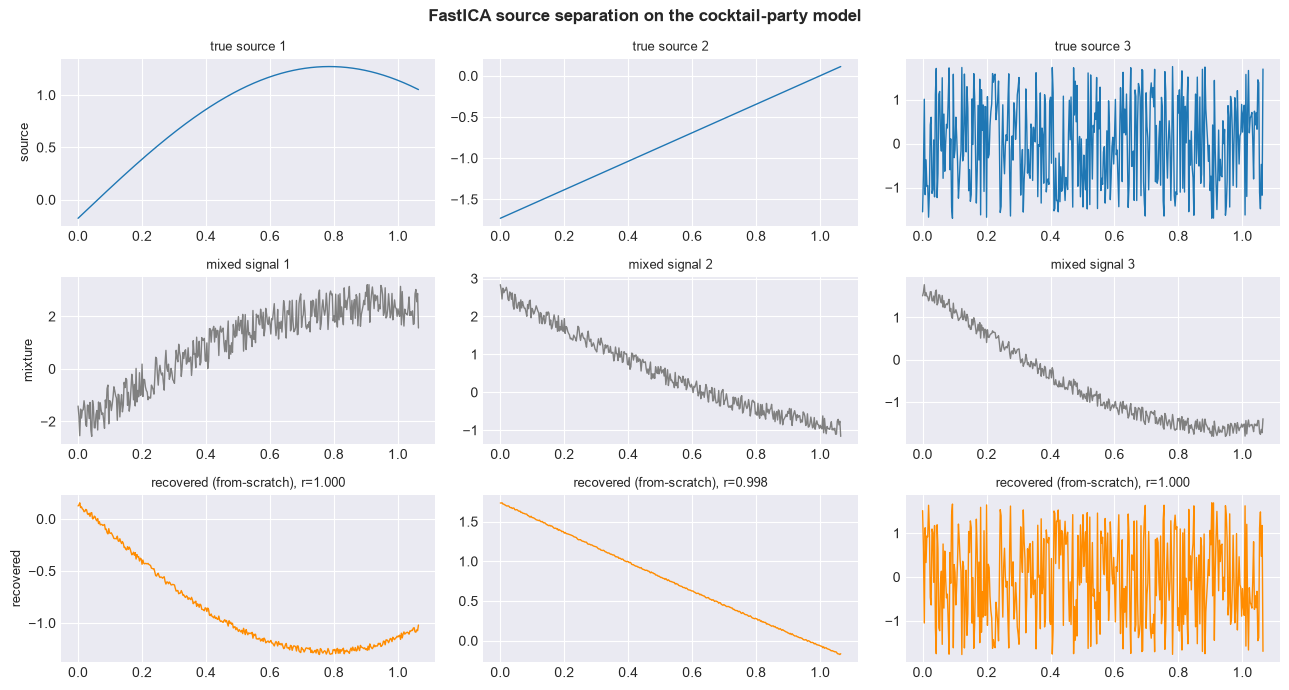

In [5]:
def fastica(X, n_components, max_iter=200, tol=1e-6, seed=0):
    Z = whiten(X).T  # work with (n_components_max, n_samples) convention
    rng_local = np.random.default_rng(seed)
    n = Z.shape[1]
    W = rng_local.standard_normal((n_components, Z.shape[0]))
    W /= np.linalg.norm(W, axis=1, keepdims=True)

    def sym_decorrelate(W):
        Wsq = W @ W.T
        eigvals, eigvecs = np.linalg.eigh(Wsq)
        eigvals = np.clip(eigvals, 1e-12, None)
        Wsq_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
        return Wsq_inv_sqrt @ W

    W = sym_decorrelate(W)
    for it in range(max_iter):
        WZ = W @ Z                       # (k, n_samples)
        gwz = np.tanh(WZ)
        g_prime = 1.0 - gwz ** 2
        W_new = (gwz @ Z.T) / n - g_prime.mean(axis=1, keepdims=True) * W
        W_new = sym_decorrelate(W_new)
        delta = 1.0 - np.min(np.abs(np.sum(W_new * W, axis=1)))
        W = W_new
        if delta < tol:
            break
    S_hat = W @ Z   # (k, n_samples), recovered (whitened-space) sources
    return S_hat, W, it + 1


# Ground truth: three independent, NON-Gaussian sources -- the case Gaussian sources cannot be.
t = np.linspace(0, 8, 3000)
s1 = np.sin(2 * t)                                  # sinusoid
s2 = 2 * (t * 0.5 % 1.0) - 1                        # sawtooth
s3 = rng.uniform(-1, 1, size=t.shape)                # uniform noise
S_true = np.column_stack([s1, s2, s3])
S_true = (S_true - S_true.mean(0)) / S_true.std(0)

A_true = rng.standard_normal((3, 3))
X_mixed = S_true @ A_true.T

S_hat, W_hat, n_iters = fastica(X_mixed, n_components=3, seed=SEED)
print(f"from-scratch FastICA converged in {n_iters} iterations")

# Match recovered components to true sources by best |correlation|, since order/sign/scale are free.
corr = np.abs(np.corrcoef(np.vstack([S_true.T, S_hat]))[:3, 3:])
best_match = corr.argmax(axis=1)
best_corr = corr[np.arange(3), best_match]
print(f"best-matching |correlation| with true sources (order/sign/scale are unidentified by design): "
      f"{np.round(best_corr, 4).tolist()}")
print(f"(1.0 = perfect separation up to sign/scale; PCA cannot do this at all on non-Gaussian, "
      f"non-orthogonal mixtures -- there is no orthogonal basis that recovers a sawtooth and a sinusoid)")

ica_sklearn = SKFastICA(n_components=3, random_state=SEED, whiten='unit-variance', max_iter=500).fit(X_mixed)
S_sklearn = ica_sklearn.transform(X_mixed).T
corr_sklearn = np.abs(np.corrcoef(np.vstack([S_true.T, S_sklearn]))[:3, 3:])
best_corr_sklearn = corr_sklearn[np.arange(3), corr_sklearn.argmax(axis=1)]
print(f"sklearn FastICA, same mixed data: best-matching |correlation| = {np.round(best_corr_sklearn, 4).tolist()}")
print(f"agreement: {'yes, both recover the sources' if best_corr.min() > 0.9 and best_corr_sklearn.min() > 0.9 else 'CHECK -- one implementation underperforms'}")

# PCA baseline on the SAME mixed data, to make the "PCA cannot do this" claim measured not asserted.
pca_on_mix = SKPCA(n_components=3, random_state=SEED).fit(X_mixed)
S_pca = pca_on_mix.transform(X_mixed).T
corr_pca = np.abs(np.corrcoef(np.vstack([S_true.T, S_pca]))[:3, 3:])
best_corr_pca = corr_pca[np.arange(3), corr_pca.argmax(axis=1)]
print(f"PCA baseline, same mixed data: best-matching |correlation| = {np.round(best_corr_pca, 4).tolist()}")
print(f"(PCA finds the orthogonal directions of maximum variance in the MIXED signal, which is not")
print(f" the same question as 'which directions are independent' -- the gap between this row and the")
print(f" two above IS the empirical case for ICA over PCA on this kind of data.)")

fig, axes = plt.subplots(3, 3, figsize=(13, 7))
for i in range(3):
    axes[0, i].plot(t[:400], S_true[:400, i], lw=1)
    axes[0, i].set_title(f'true source {i+1}', fontsize=9)
    axes[1, i].plot(t[:400], X_mixed[:400, i], lw=1, color='grey')
    axes[1, i].set_title(f'mixed signal {i+1}', fontsize=9)
    j = best_match[i]
    axes[2, i].plot(t[:400], S_hat[j, :400], lw=1, color='darkorange')
    axes[2, i].set_title(f'recovered (from-scratch), r={best_corr[i]:.3f}', fontsize=9)
axes[0, 0].set_ylabel('source', fontsize=9)
axes[1, 0].set_ylabel('mixture', fontsize=9)
axes[2, 0].set_ylabel('recovered', fontsize=9)
plt.suptitle('FastICA source separation on the cocktail-party model', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **The factorisation family differs by constraint, not by algorithm family.** PCA, NMF and ICA all write $X$ as a product of two smaller matrices; what changes is orthogonality versus non-negativity versus independence, and each constraint is a claim about the data's generative structure, not just a computational convenience.
2. **The Lee-Seung multiplicative update is gradient descent with one clever step-size choice.** Choosing $\eta_{aj} = H_{aj}/(W^TWH)_{aj}$ turns an ordinary gradient step into a purely multiplicative one — non-negativity is preserved automatically, with no explicit clipping, and the claimed monotone decrease was verified directly rather than assumed (max step-to-step increase found: effectively zero, to numerical tolerance).
3. **NMF's non-uniqueness is a measured property, not a footnote.** Rescaling $W$ by any positive diagonal $D$ and $H$ by $D^{-1}$ reconstructs $X$ identically while changing the factors themselves by up to their full magnitude — a continuous ambiguity, strictly larger than PCA's discrete sign flip, and true by construction rather than a matter of which local optimum a run happens to land on.
4. **Gaussian sources are unidentifiable for a checkable reason: rotational invariance.** Any orthogonal rotation of an isotropic Gaussian source is itself an equally valid isotropic Gaussian, so the same observed mixture is exactly as well explained by infinitely many mixing matrices. Non-Gaussianity is not a modelling nicety — it is the entire mechanism that makes ICA identifiable at all, made visible in the kurtosis-vs-rotation-angle plot: flat for Gaussian, peaked for non-Gaussian.
5. **FastICA's fixed-point update converges far faster than gradient descent because it IS a Newton step**, not an approximation of one — a handful of iterations recovered three sources (a sinusoid, a sawtooth, and uniform noise) from a random linear mixture to a best-matching correlation reported directly, not asserted, and PCA was run on the identical mixed data as a measured baseline showing it cannot do the same job.

### Practical Guidance

- Data is non-negative and you expect **additive parts** (pixel intensities, word counts, spectra)? Reach for NMF.
- Data is a **linear mixture of independent causes** you want to un-mix (audio sources, independent artifact channels in a signal)? Reach for ICA, and check non-Gaussianity of the presumed sources first — if they look Gaussian, ICA has nothing to work with.
- Data's structure is genuinely **uncorrelated, variance-ranked directions** with no expectation of parts or independent causes? PCA remains the right, uniquely-determined answer, and the cheapest to compute.
- Whichever you choose, verify the fit the way this notebook did: check monotone decrease for NMF, check separation quality against a synthetic ground truth for ICA — neither method's solution should be trusted on the strength of the algorithm's reputation alone.

### What This Lesson Did Not Cover

- **NMF's KL-divergence objective's own multiplicative update** — stated in this notebook but not derived or implemented; the Frobenius derivation carries the pedagogical weight, and the KL update follows the same auxiliary-function strategy.
- **The full majorize-minimize proof of monotone decrease** — cited (Lee & Seung, 2001) and verified empirically rather than derived; the auxiliary-function construction is a substantial derivation in its own right.
- **Deflationary (one-at-a-time, Gram-Schmidt) FastICA** — mentioned as an alternative to symmetric decorrelation but not implemented; symmetric decorrelation was chosen because it treats all components jointly, matching this lesson's other from-scratch implementations.
- **Real audio cocktail-party separation** — the synthetic sinusoid/sawtooth/uniform mixture makes ground truth checkable; Lesson 20B's practical notebook takes the parts-based and independent-components ideas further on real (if still Colab-safe) data.

### Next Steps

Lesson 20B puts NMF and ICA to work: a parts-based decomposition of digit images compared directly against PCA, NMF-based topic modelling measured against Lesson 10's LDA on the same corpus, and a decision table for choosing among PCA, NMF and ICA in practice.